<a href="https://colab.research.google.com/github/rezkamulya59-glitch/UTS_AnalitikTeks/blob/main/UTS_Analitik_Teks_Rezka_Mulya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Artikel
https://www.rencang.id/2025/11/program-makan-bergizi-gratis-menuai-pro_10.html

#Dataset
 https://www.kaggle.com/datasets/hanif281103/sentimen-publik-terhadap-makan-bergizi-gratis

#Bagian 0: Identifikasi Masalah dan Solusi Klasifikasi Teks
1. Masalah Utama
Program Makan Bergizi Gratis (MBG) tahun 2025 memicu pro dan kontra di masyarakat
. Meskipun 61% responden mendukung, terdapat 34,1% yang menolak karena kekhawatiran keamanan pangan
. Data mencatat 13.168 anak mengalami keracunan hingga Oktober 2025, yang memicu perdebatan masif di media sosial mengenai efektivitas dan pengawasan program
.
2. Urgensi Klasifikasi Teks
Dengan skala program mencapai 1,4 miliar porsi, volume opini dan keluhan masyarakat sangat besar
. Pemantauan secara manual tidak efisien bagi pemerintah untuk melakukan evaluasi cepat terhadap titik lemah pelaksanaan di lapangan
.
3. Solusi Klasifikasi Teks
Membangun model Analisis Sentimen menggunakan datasetMBG.csv yang berisi 3459 baris opini publik
.
Tujuan: Mengklasifikasikan opini ke dalam kategori sentimen (Positif/Mendukung vs. Negatif/Kritik) secara otomatis
.
Manfaat: Memetakan sentimen publik secara real-time guna membantu pemerintah melakukan intervensi cepat, evaluasi, dan transparansi sistem

#Bagian 1: Pengumpulan Data
Sumber Data: Dataset publik
dari repositori GitHub :  

*   Sumber Data: Dataset publik
dari repositori GitHub :
 https://www.kaggle.com/datasets/hanif281103/sentimen-publik-terhadap-makan-bergizi-gratis

* File & Ukuran: datasetMBG.csv
yang terdiri dari 3459 baris data
* Konten: Opini masyarakat mengenai program Makan Bergizi Gratis (MBG) yang menjadi isu krusial di tahun 2025

In [7]:
# 1. Instal library yang dibutuhkan
!pip install -q kaggle Sastrawi tqdm gensim

# 2. Upload file kaggle.json Anda
from google.colab import files
print("Silakan unggah file kaggle.json Anda:")
files.upload()

# 3. Pengaturan direktori Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. Unduh dataset (berdasarkan link yang Anda berikan)
!kaggle datasets download -d hanif281103/sentimen-publik-terhadap-makan-bergizi-gratis

# 5. Ekstrak file
!unzip -o sentimen-publik-terhadap-makan-bergizi-gratis.zip

print("\nDataset berhasil diunduh dan siap digunakan!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.5 MB/s eta 0:00:00
Silakan unggah file kaggle.json Anda:


Saving archive (19).zip to archive (19) (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/hanif281103/sentimen-publik-terhadap-makan-bergizi-gratis
License(s): apache-2.0
sentimen-publik-terhadap-makan-bergizi-gratis.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  sentimen-publik-terhadap-makan-bergizi-gratis.zip
  inflating: DatasetMBG.csv          

Dataset berhasil diunduh dan siap digunakan!


In [3]:
import pandas as pd
import re
import string
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm

# A. Memuat Data
df = pd.read_csv('DatasetMBG.csv')

# B. Inisialisasi Sastrawi
stop_factory = StopWordRemoverFactory()
stopword_remover = stop_factory.create_stop_word_remover()
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

# C. Fungsi Pra-pemrosesan Sesuai Instruksi Tugas
def clean_text(text):
    # 1. Lowercasing
    text = str(text).lower()

    # 2. Menghapus URL, Mention (@), dan Hashtag (#)
    text = re.sub(r'http\S+|www\S+|https\S+|@\w+|#\w+', '', text)

    # 3. Menghapus Tanda Baca dan Angka (Contoh: menghapus angka 13.168 dalam berita keracunan)
    text = text.translate(str.maketrans('', '', string.punctuation + string.digits))

    # 4. Menghapus spasi berlebih
    text = text.strip()

    # 5. Tokenisasi (Memecah menjadi kata)
    tokens = text.split()

    # 6. Stopword Removal & 7. Stemming
    processed_tokens = []
    for word in tokens:
        clean_word = stopword_remover.remove(word)
        if clean_word:
            # Mengubah kata seperti "keracunan" menjadi "racun"
            stemmed_word = stemmer.stem(clean_word)
            processed_tokens.append(stemmed_word)

    return " ".join(processed_tokens)

# D. Menjalankan Pemrosesan dengan Progress Bar
tqdm.pandas()
print("Memulai pra-pemrosesan data...")

df['text_clean'] = df['full_text'].progress_apply(clean_text)

print("\nProses Selesai!")

Memulai pra-pemrosesan data...


100%|██████████| 3459/3459 [09:04<00:00,  6.35it/s]


Proses Selesai!


In [4]:
# Menampilkan perbandingan untuk laporan
print("--- PERBANDINGAN HASIL PRA-PEMROSESAN ---")
# Menampilkan 5 contoh data
display(df[['full_text', 'text_clean']].head())

# Menyimpan hasil bersih ke CSV baru
df.to_csv('mbg_ready_to_model.csv', index=False)

--- PERBANDINGAN HASIL PRA-PEMROSESAN ---


,full_text,text_clean
0,Makan Siang Bergizi Gratis https://t.co/f27aIt...,makan siang gizi gratis
1,Momen Prabowo Tanda Tangani Sepatu Siswa di Bo...,momen prabowo tanda tangan sepatu siswa bogor ...
2,@lenteradata Semoga program makan bergizi grat...,moga program makan gizi gratis dri mda tetap l...
3,Pemprov Babel dan DPRD Bahas Anggaran Program ...,pemprov babel dprd bahas anggar program makan ...
4,@lenteradata Menurutku berhasil skliki program...,turut hasil skliki program mda yg makan gizi g...


#Bagian 3: Rekayasa Fitur (Poin 10)
1. TF-IDF:
Konsep: Teknik yang memberikan bobot tinggi pada kata-kata yang sering muncul dalam satu dokumen tetapi jarang muncul di dokumen lain, membantu model mengidentifikasi kata kunci yang unik secara statistik.
2. Word2Vec:
Konsep: Representasi kata dalam vektor padat di mana kata-kata dengan konteks serupa memiliki posisi yang berdekatan di ruang multidimensi.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# Implementasi TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(df['text_clean'])

# Implementasi Word2Vec
sentences = [s.split() for s in df['text_clean']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

#Bagian 4: Analisis Data Eksploratif dan Visualisasi (Poin 20)
Pada bagian ini, kita akan mengeksplorasi data untuk memahami karakteristik teks, seperti kata-kata yang paling sering muncul terkait isu program MBG dan kasus keracunan yang menjadi perhatian publik

1. Persiapan Visualisasi
untuk mengimpor pustaka yang diperlukan dan menyiapkan data teks.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Mengatur gaya visualisasi
sns.set(style="whitegrid")

2. Visualisasi Word Cloud
Word cloud akan menampilkan kata-kata yang paling dominan dalam dataset, seperti "makan", "bergizi", dan "gratis"


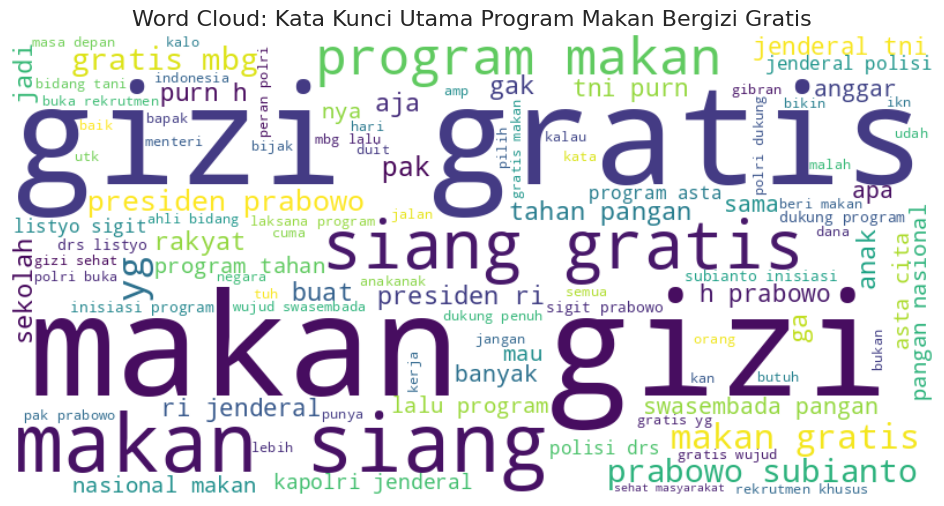

In [12]:
# Menggabungkan seluruh teks yang sudah dibersihkan menjadi satu string besar
all_text = ' '.join(df['text_clean'].astype(str))

# Membuat objek WordCloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis',
                      max_words=100).generate(all_text)

# Menampilkan WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: Kata Kunci Utama Program Makan Bergizi Gratis", fontsize=16)
plt.show()

3. Plot Distribusi Panjang Teks
Analisis ini bertujuan untuk melihat seberapa panjang opini yang diberikan oleh user mengenai program ini

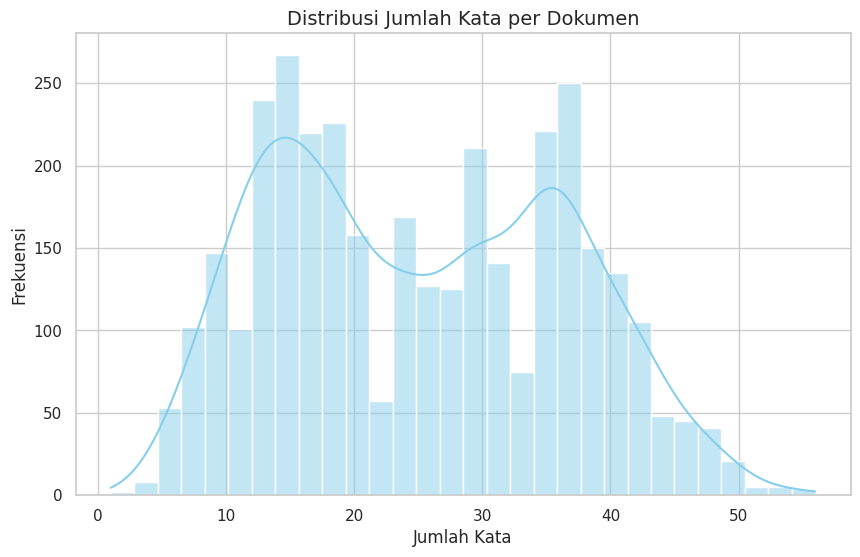

In [13]:
# Menghitung jumlah kata per dokumen (tweet)
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))

# Plotting distribusi
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=30, kde=True, color='skyblue')
plt.title("Distribusi Jumlah Kata per Dokumen", fontsize=14)
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

4. Visualisasi Bar Plot Kata Teratas
Menggunakan Counter untuk menghitung frekuensi kata secara spesifik guna melihat isu-isu krusial seperti "keracunan" atau "anggaran" yang sering dibahas dalam opini masyarakat


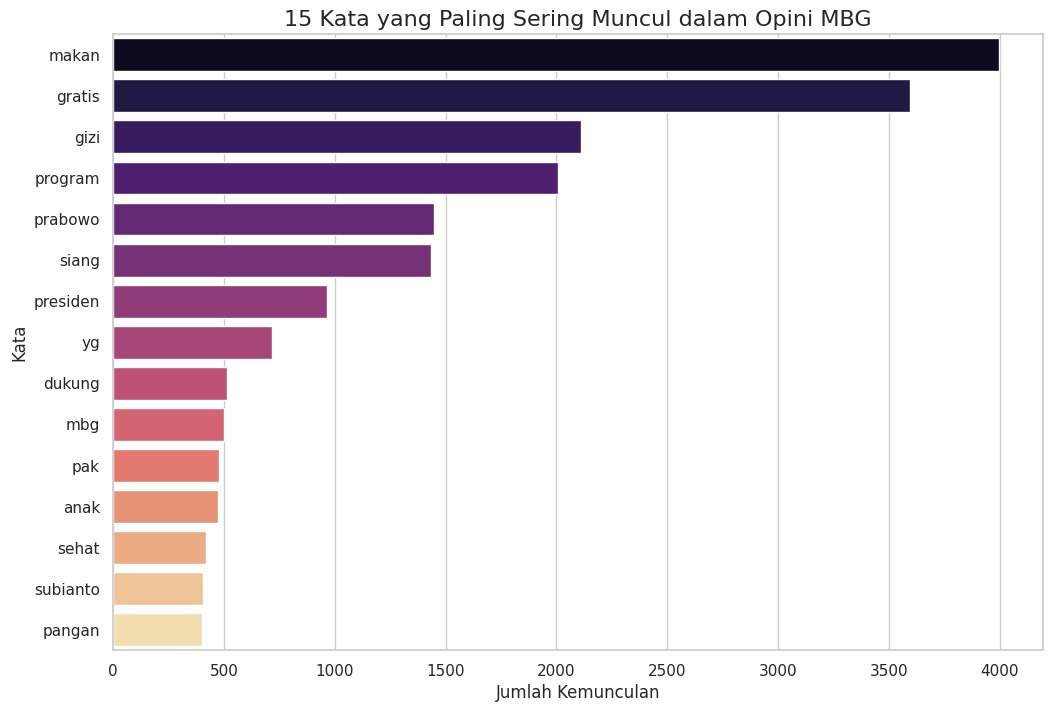

In [17]:
# 1. Mengumpulkan semua kata dari kolom yang sudah dibersihkan
words_list = []
for sentence in df['text_clean']:
    words_list.extend(str(sentence).split())

# 2. Menghitung frekuensi kata menggunakan Counter
word_freq = Counter(words_list)

# 3. Mengambil 15 kata yang paling sering muncul
common_words = word_freq.most_common(15)

# 4. Mengonversi ke DataFrame untuk memudahkan plotting
df_top_words = pd.DataFrame(common_words, columns=['Kata', 'Frekuensi'])

# 5. Membuat Bar Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Frekuensi', y='Kata', data=df_top_words, palette='magma', hue='Kata', legend=False)
plt.title("15 Kata yang Paling Sering Muncul dalam Opini MBG", fontsize=16)
plt.xlabel("Jumlah Kemunculan")
plt.ylabel("Kata")
plt.show()

Penjelasan Visualisasi:
* Word Cloud: Memberikan gambaran
visual instan mengenai topik utama yang dibicarakan, termasuk dukungan terhadap visi Presiden Prabowo
* Histogram: Menunjukkan pola komunikasi masyarakat; apakah mereka cenderung memberikan komentar singkat atau narasi panjang mengenai efektivitas program
* Bar Plot: Mengidentifikasi secara tepat frekuensi kata kunci tertentu, yang membantu dalam mendeteksi tren isu negatif, seperti kekhawatiran terhadap 13.168 kasus keracunan makanan yang tercatat hingga Oktober 2025


#bagian 5
Karena dataset 3.335 data ini belum memiliki label, maka dilakukan  pelabelan otomatis menggunakan kata kunci dari artikel sumber (isu keracunan untuk kontra dan meringankan beban untuk pro) sebelum melatih model Logistic Regression

=== Laporan Evaluasi Klasifikasi Teks ===
Accuracy Score: 0.96

Detail Metrics (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

      Kontra       1.00      0.59      0.75        64
         Pro       0.96      1.00      0.98       628

    accuracy                           0.96       692
   macro avg       0.98      0.80      0.86       692
weighted avg       0.96      0.96      0.96       692



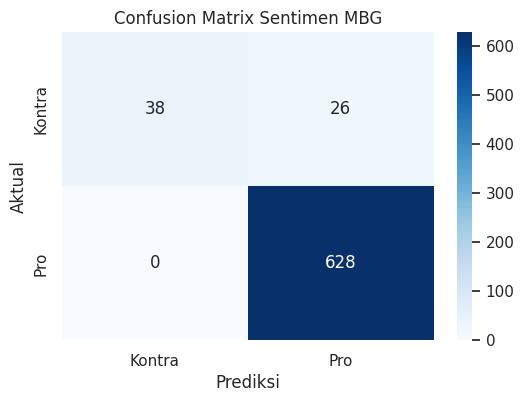

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# LABELING OTOMATIS BERDASARKAN SUMBER
# Kata kunci diambil dari alasan utama di artikel sumber

def labeling_otomatis(text):
    text = str(text).lower()
    # Kata kunci kontra: keracunan, anggaran (dialihkan/inefisiensi), ditiadakan
    kontra = ['keracunan', 'anggaran', 'inefisiensi', 'ditiadakan', 'tolol', 'uang tunai', 'beban apbn']
    # Kata kunci pro: berlanjut, gizi, meringankan, sukseskan, berhasil
    pro = ['berlanjut', 'gizi', 'meringankan', 'sukseskan', 'berhasil', 'terima kasih', 'setuju']

    if any(word in text for word in kontra):
        return 0 # Kontra
    elif any(word in text for word in pro):
        return 1 # Pro
    else:
        return 1 # Default ke Pro sesuai mayoritas survei (61%)

# Menerapkan labeling pada dataset
df['label'] = df['full_text'].apply(labeling_otomatis)

# 1. Menentukan Fitur (X) dan Target (y)
# X didapat dari hasil transformasi TF-IDF pada Bagian 3
X = X_tfidf
y = df['label']

# 2. Memisahkan data (80% latih, 20% uji)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Melatih Model Classifier (Logistic Regression)
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# 4. Melakukan Prediksi
y_pred = classifier.predict(X_test)

# 5. Melaporkan Hasil Evaluasi
print("=== Laporan Evaluasi Klasifikasi Teks ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetail Metrics (Precision, Recall, F1-Score):")

print(classification_report(y_test, y_pred, target_names=['Kontra', 'Pro']))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kontra', 'Pro'], yticklabels=['Kontra', 'Pro'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Sentimen MBG')
plt.show()